# Blume-Capel model with muca in the chrystal field

In [1]:
using Pkg
Pkg.activate(dirname(@__DIR__))
Pkg.instantiate()

using Revise
using MonteCarloX
using SpinSystems
using Random
using Plots

  Activating project at `~/.julia/dev/MonteCarloX.jl/examples`
Precompiling packages...
   2992.9 ms  ✓ SpinSystems
  1 dependency successfully precompiled in 6 seconds. 222 already precompiled.


Build the Blume-Capel model with Hamiltonian
$$
H = -J\sum_{ij}s_i s_j +\Delta\sum s_i^2
$$

In [4]:
L=8
sys = BlumeCapel([8,8])
# weights for the sum_pair_interacionts (can use delta_pair_interaction)
logweight_pair = BoltzmannLogWeight(β=1.0)
# weights for the sum_spin2
logweight_spin2 = MulticanonicalLogWeight(0:1:length(sys.spins))
# so define a final logweight as the sum of the two
@inline logweight(H::NTuple{2,Real}) = logweight_pair(H[1]) + logweight_spin2(H[2])

logweight (generic function with 2 methods)

In [ ]:
function spin_flip!(sys::SpinSystems.AbstractBlumeCapel, alg::AbstractImportanceSampling)
    i = pick_site(alg.rng, length(sys.spins))
    s_new = SpinSystems._propose_state(alg.rng, sys.spins[i])
    Δpair, Δspin, Δspin2 = SpinSystems.propose_changes(sys, i, s_new)
    # declare H_old and H_new as tuples of the two relevant observables
    H_old = (sys.J*sys.sum_pair_interactions, sys.sum_spins2)
    H_new = (H_old[1] + Δpair, H_old[2] + Δspin2)
    accept!(alg, H_new, H_old) && modify!(sys, i, s_new, Δpair, Δspin, Δspin2)
    # Issue: this does not record the histogram correclty, because the record! call in accept is not forwarded to the subpart of the logweight function. 
    #IDEA: define an NTuple necessity for logweight so that actually all subweights are part of the algorihtm?
    return nothing
end

spin_flip! (generic function with 1 method)

In [17]:
rng = Xoshiro(42)
alg = Metropolis(rng, logweight)

# thermalization
for i in 1:1000
    spin_flip!(sys, alg)
end
# reset alg -> which also resets the histogram
reset!(alg) 
# recording
for i in 1:10_000_000
    spin_flip!(sys, alg)
end
# update weights)
update!(logweight_spin2)
# continue
# for pmuca: simply do everything on MulticanonicalLogWeight ...
# this then becomes very similar for parallel tempering as an extra layer that just helps exchange states

In [23]:
logweight_spin2.logweight

BinnedObject{1, Float64, MonteCarloX.DiscreteBinning{Int64}}([0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], (MonteCarloX.DiscreteBinning{Int64}(0, 1, 65),))

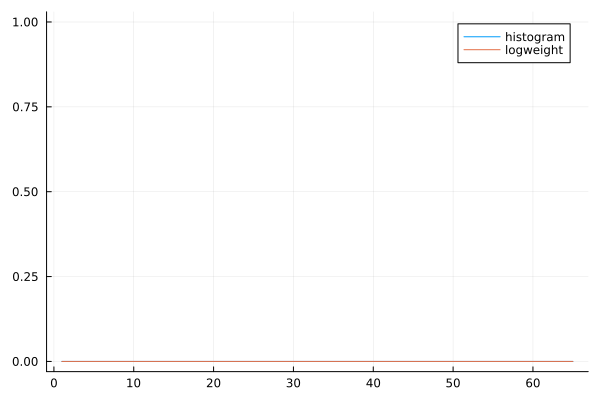

In [25]:
# plot the histogram, the logweight_spin2, and the logweight
p1 = plot(logweight_spin2.histogram.values, label="histogram")
plot!(p1,logweight_spin2.logweight.values, label="logweight")